---
# Tiny Large Language Model
---

In this notebook we train a small LLM on the tokenized coding instruction dataset.

**Do not copy your files from 13b-tokenizer. We provide clean implementations here. Focus on the LLM implementation.**

In [1]:
import importlib
from pathlib import Path
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
import dataset
import llm
import sampling
import tests
import visual
from instruction_dataset import DEFAULT_OUTPUT_PATH, InstructionDataset
%matplotlib inline

---
## Load the raw Instruction Dataset
---

Each row contains an instruction, optional input, and output code/text.

In [2]:
data = InstructionDataset(DEFAULT_OUTPUT_PATH)
len(data), data[0]

(121959,
 {'instruction': 'Create a function to calculate the sum of a sequence of integers.',
  'input': '[1, 2, 3, 4, 5]',
  'output': '# Python code\ndef sum_sequence(sequence):\n  sum = 0\n  for num in sequence:\n    sum += num\n  return sum'})

---
## Train or Load the BPE Tokenizer
---

We reuse the byte-level BPE tokenizer and save the trained tokenizer to disk so the big model run can be reproduced later. 

If a saved tokenizer is already available in the cache folder, we load it instead of training it again.

In [3]:
cache_dir = Path("cache")
cache_dir.mkdir(parents=True, exist_ok=True)
tokenizer_path = cache_dir / "bpe_tokenizer.json"

if tokenizer_path.exists():
    bpe = dataset.load_bpe_tokenizer(tokenizer_path)
    tokenizer_source = "loaded"
    print("Loaded BPE tokenizer from " + str(tokenizer_path))
else:
    print("BPE tokenizer not found at " + str(tokenizer_path) + "; training it now.")
    bpe = dataset.train_bpe_tokenizer(
        data,
        vocab_size=640,
        min_frequency=2,
        max_examples=2500,
    )
    dataset.save_bpe_tokenizer(bpe, tokenizer_path)
    tokenizer_source = "trained"
    print("Saved BPE tokenizer to " + str(tokenizer_path))

bpe.vocab_size, tokenizer_source, tokenizer_path

Loaded BPE tokenizer from cache\bpe_tokenizer.json


(640, 'loaded', WindowsPath('cache/bpe_tokenizer.json'))

---
## Create Tokenized Dataset
---

`BPE_Token_Dataset` returns fixed-length examples with two tensors:

- `model_input`: token ids fed into the Transformer.
- `labels`: shifted next-token ids, with `-100` where the loss should be ignored.

Because every example already has the same length, PyTorch's default DataLoader stacks the dictionaries automatically. Have a look:

In [4]:
preview_data = [data[index] for index in range(64)]
token_data = dataset.BPE_Token_Dataset(preview_data, bpe, max_length=384, show_progress=False)
batch = next(iter(DataLoader(token_data, batch_size=8, shuffle=True)))
{name: tuple(value.shape) for name, value in batch.items()}

{'model_input': (8, 384), 'labels': (8, 384)}

---
## Causal Mask
---

A language model may use the past and current token to predict the next token, but it must not look into the future.

A causal mask blocks attention to positions on the upper-right side of the attention matrix.

## **Task:**

Implement `make_causal_mask` in `llm.py`.

**Hints:**

- The mask should have shape `(seq_len, seq_len)`.
- Entries above the diagonal should be `True`.
- Entries on and below the diagonal should be `False`.

Run the cell below.

In [5]:
importlib.reload(dataset)
importlib.reload(llm)
importlib.reload(tests)
tests.test_causal_mask()

---
## Tiny Transformer Model
---

The model is a small causal Transformer:

- token embeddings turn token ids into vectors,
- position embeddings tell the model where each token is,
- Transformer encoder layers mix information from previous positions,
- a linear output head predicts the next-token logits.

## **Task:**

Implement `TinyLLM` in `llm.py`.

**Hints:**

- Use high-level PyTorch.
- Use `nn.Embedding` for token and positional embeddings.
- Use `nn.TransformerEncoderLayer` and set `batch_first=True`, set `dim_feedforward` four times the embedding dimension, use Dropout and GELU activation and set other necessary parameters.
- Then use `nn.TransformerEncoder` which has an argument `mask=` in its forward call.
- Mask entries above the diagonal should be `True`.
- Mask entries on and below the diagonal should be `False`.
- Optional: Precompute stuff like position ids or the causal mask once in `__init__` and store them with `register_buffer`. You can also compute them in forward.

In [6]:
importlib.reload(dataset)
importlib.reload(llm)
importlib.reload(tests)
tests.test_tiny_llm_forward()

---
## Training Step
---

The model predicts logits for every token position. Cross entropy compares those logits with `labels`.

The labels use `-100` for prompt and padding positions, and `torch.nn.functional.cross_entropy` ignores those positions with `ignore_index=-100`.

## **Task:**

Implement `training_step` in `llm.py`.

**Hints:**

- Don't forget `model.train()`, `device` and `ignore_index`.

In [7]:
importlib.reload(dataset)
importlib.reload(llm)
importlib.reload(tests)
tests.test_tiny_dataloader()
tests.test_training_step()
tests.test_train_tiny_llm()

Pre-tokenizing BPE dataset:   0%|          | 0/2 [00:00<?, ?examples/s]

d:\Deep Learning\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Pre-tokenizing BPE dataset:   0%|          | 0/3 [00:00<?, ?examples/s]

d:\Deep Learning\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


---
## Text Generation
---

After training, generation runs one token at a time. The model sees the current context, predicts logits for the next token, samples one token, appends it, and repeats.

## **Task:**

Implement `sample_next_token` and `generate_tokens` in `sampling.py`.

**Hints:**
- Encode the prompt.
- Don't forget `model.eval()` and applying temperature.
- Useful functions:  `torch.softmax`, `torch.multinomial`
- Sampling the EOS token terminates token generation.
- When `temperature=0` then apply greedy decoding using `torch.argmax`.

In [8]:
importlib.reload(dataset)
importlib.reload(llm)
importlib.reload(sampling)
importlib.reload(tests)
tests.test_sample_next_token()
tests.test_generation_helpers()

---
## Tiny Overfit Check - Training and Text Generation
---

Before the longer training run, train a fresh tiny model on three examples until it fully memorizes them. Greedy sampling should reproduce the expected outputs.

**This needs to work, before you start longer training runs!**

Pre-tokenizing BPE dataset:   0%|          | 0/3 [00:00<?, ?examples/s]

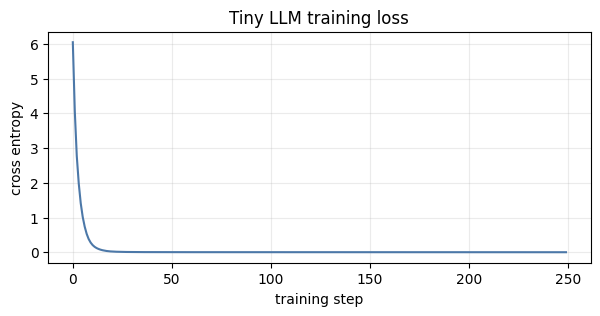

In [9]:
importlib.reload(dataset)
importlib.reload(llm)
importlib.reload(sampling)
torch.manual_seed(0)

tiny_examples = [
    {
        "instruction": "Return only the word red.",
        "input": "",
        "output": "red",
    },
    {
        "instruction": "Return the word blue twice.",
        "input": "",
        "output": "blue blue",
    },
    {
        "instruction": "Return the word green and then backwards.",
        "input": "",
        "output": "green neerg",
    },
]

tiny_bpe = dataset.train_bpe_tokenizer(tiny_examples, vocab_size=320, min_frequency=1)
tiny_context_window = 96
tiny_device = "cuda" if torch.cuda.is_available() else "cpu"

tiny_loader = llm.make_tiny_dataloader(
    tiny_examples,
    tiny_bpe,
    max_length=tiny_context_window,
    batch_size=len(tiny_examples),
    max_examples=len(tiny_examples),
    shuffle=True,
    num_workers=0,
)

tiny_model = llm.TinyLLM(
    vocab_size=tiny_bpe.vocab_size,
    context_window=tiny_context_window,
    embedding_dim=64,
    num_heads=4,
    num_layers=2,
    dropout=0.0,
)

tiny_losses = llm.train_tiny_llm(
    tiny_model,
    tiny_loader,
    steps=250,
    learning_rate=5e-3,
    device=tiny_device,
)
visual.plot_training_loss(tiny_losses);

In [10]:
matches = []

for example in tiny_examples:
    generated = sampling.answer_instruction(
        tiny_model,
        tiny_bpe,
        instruction=example["instruction"],
        input_text=example["input"],
        max_new_tokens=20,
        temperature=0,
        device=tiny_device,
    ).strip()

    expected = example["output"].strip()
    matches.append(generated == expected)

    print("instruction:", example["instruction"])
    print("expected:   ", repr(expected))
    print("generated:  ", repr(generated))
    print()

print("exact matches:", sum(matches), "/", len(matches))

instruction: Return only the word red.
expected:    'red'
generated:   'red'

instruction: Return the word blue twice.
expected:    'blue blue'
generated:   'blue blue'

instruction: Return the word green and then backwards.
expected:    'green neerg'
generated:   'green neerg'

exact matches: 3 / 3


---
## Big Training Run
---

The settings below configure the longer run. If your compute resources allow it, create a bigger model and do even longer training.

In [11]:
context_window = 384
batch_size = 64
max_examples = 120000
train_steps = 25100
learning_rate = 4e-4
num_workers = 0

lr_warmup_steps = 200
min_learning_rate_ratio = 0.1
checkpoint_every = 5000
progress_every = 25
checkpoint_dir = cache_dir / "checkpoints"
tokenized_dataset_path = cache_dir / "tokenized_dataset.pt"

---
## Train the Tiny LLM
---

Create the tokenized dataset. This can take very long. By default, the tokenized dataset is loaded from the cache folder to save some time.

In [12]:
importlib.reload(dataset)
importlib.reload(llm)
importlib.reload(visual)
checkpoint_dir.mkdir(parents=True, exist_ok=True)
dashboard = visual.TrainingDashboard(total_steps=train_steps)

preprocess_workers = 24 # your number of CPU cores
train_loader = llm.make_tiny_dataloader(
    data,
    bpe,
    max_length=context_window,
    batch_size=batch_size,
    max_examples=max_examples,
    num_workers=num_workers,
    preprocess_workers=preprocess_workers,
    cache_path=tokenized_dataset_path,
)

Loaded tokenized dataset cache from cache\tokenized_dataset.pt


This loop repeatedly samples tokenized batches and performs next-token prediction updates. The dashboard updates during training, and checkpoints are written every `checkpoint_every` steps.

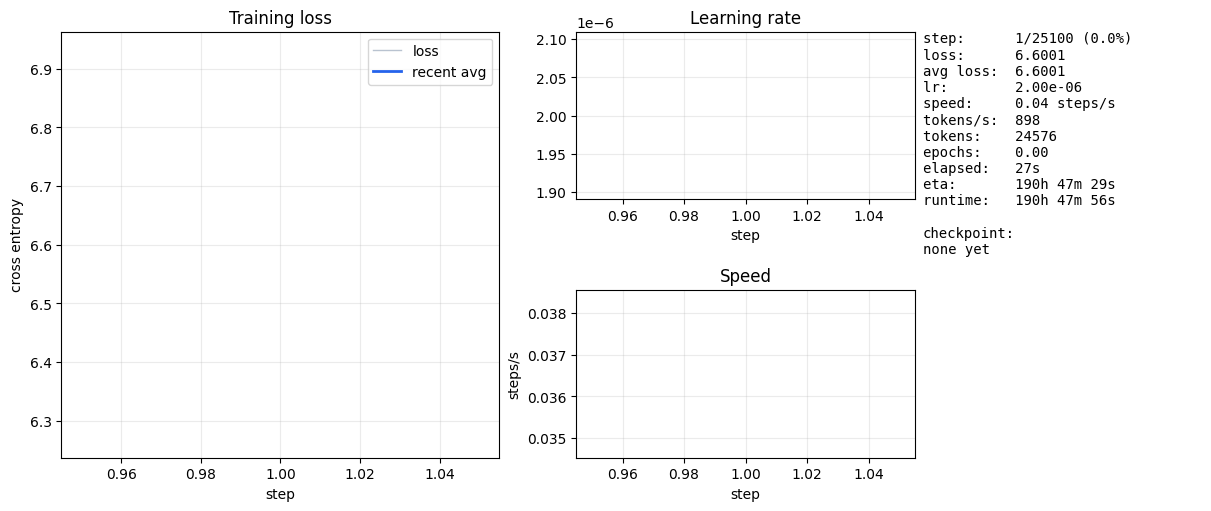

KeyboardInterrupt: 

In [14]:
# Model from solution - 33.6M weights,
# 22GB VRAM needed with 96 batch_size. 20k steps for 1.5h on RTX 5090 32GB
'''
model = llm.TinyLLM(
    vocab_size=bpe.vocab_size,
    context_window=context_window,
    embedding_dim=384,
    num_heads=6,
    num_layers=18,
    dropout=0.1,
)
'''

model = llm.TinyLLM(
    vocab_size=bpe.vocab_size,
    context_window=context_window,
    embedding_dim=256,
    num_heads=4,
    num_layers=8,
    dropout=0.05,
)


losses = llm.train_tiny_llm(
    model,
    train_loader,
    steps=train_steps,
    learning_rate=learning_rate,
    warmup_steps=lr_warmup_steps,
    min_learning_rate_ratio=min_learning_rate_ratio,
    checkpoint_dir=checkpoint_dir,
    checkpoint_every=checkpoint_every,
    save_final_checkpoint=True,
    checkpoint_prefix="tiny_llm",
    checkpoint_metadata={"tokenizer_path": str(tokenizer_path)},
    progress_callback=dashboard,
    progress_every=progress_every,
)
training_history = dashboard.history

In [ ]:
visual.plot_training_history(training_history);

---
## Generate Answers
---

The trained model, checkpoints, and tokenizer are now saved in `cache`.

Continue with `../13d-fun/fun.ipynb` to reload them and generate answers.